# 10. Revision — DFS Kaplan–Meier figures (Figure 3 & Figure S2)

Regenerates the derivation-cohort disease-free-survival figures for the harmonized model and a consistent visual style. Risk groups use the finalized model's **pooled out-of-fold** predictions at the prespecified cutoff 0.12 (matching Table 2 / notebook 7). Style: **high risk = red, low risk = blue** (consistent with the external Figure S4 in notebook 9), censoring ticks shown, and numbers-at-risk tables added. Two derivation patients lack a disease-free-survival time and are excluded, so the DFS analysis n = 329.

In [1]:
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.plotting import add_at_risk_counts
SEED=8251; CUT=0.120; HIGH='#d62728'; LOW='#1f77b4'
def find_data_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for c in (base/'local_data', base/'stage_III_colon_edr'/'local_data'):
            if c.exists(): return c
    raise FileNotFoundError('local_data not found; see README')
D=find_data_dir(); deriv=pd.read_parquet(D/'all_cases_prepared_for_ML.parquet')
XGB=dict(n_estimators=50,max_depth=2,learning_rate=0.05,gamma=1.0,min_child_weight=1,subsample=0.9,
         colsample_bytree=0.6,reg_alpha=0.5,reg_lambda=1.0,eval_metric='logloss',random_state=SEED,n_jobs=1)
def base_X(df):
    X=pd.get_dummies(df[['AJCC_Substage','PNI','LNR','Differentiation']],columns=['AJCC_Substage'])
    X['PNI']=X['PNI'].astype(float); X['Differentiation']=X['Differentiation'].astype(float)
    return X.replace([np.inf,-np.inf],np.nan)
# finalized-model pooled OOF on the derivation cohort
X=base_X(deriv).reset_index(drop=True); y=deriv['edr_18m'].astype(int).reset_index(drop=True)
ratio=float((y==0).sum()/(y==1).sum()); oof=np.zeros(len(y))
for tr,te in StratifiedKFold(5,shuffle=True,random_state=SEED).split(X,y):
    m=CalibratedClassifierCV(XGBClassifier(**XGB,scale_pos_weight=ratio),method='isotonic',cv=3)
    p=Pipeline([('imp',KNNImputer(n_neighbors=5)),('m',m)]); p.fit(X.iloc[tr],y.iloc[tr]); oof[te]=p.predict_proba(X.iloc[te])[:,1]
df=deriv.reset_index(drop=True).copy(); df['ML_Prob']=oof
df['DFS_Event']=((df['Recurrence']==1)|(df['Death']==1)).astype(int)
df=df.dropna(subset=['DFS_Months']).copy()
print('DFS analysis n =',len(df),'| DFS events =',int(df['DFS_Event'].sum()))

DFS analysis n = 329 | DFS events = 130


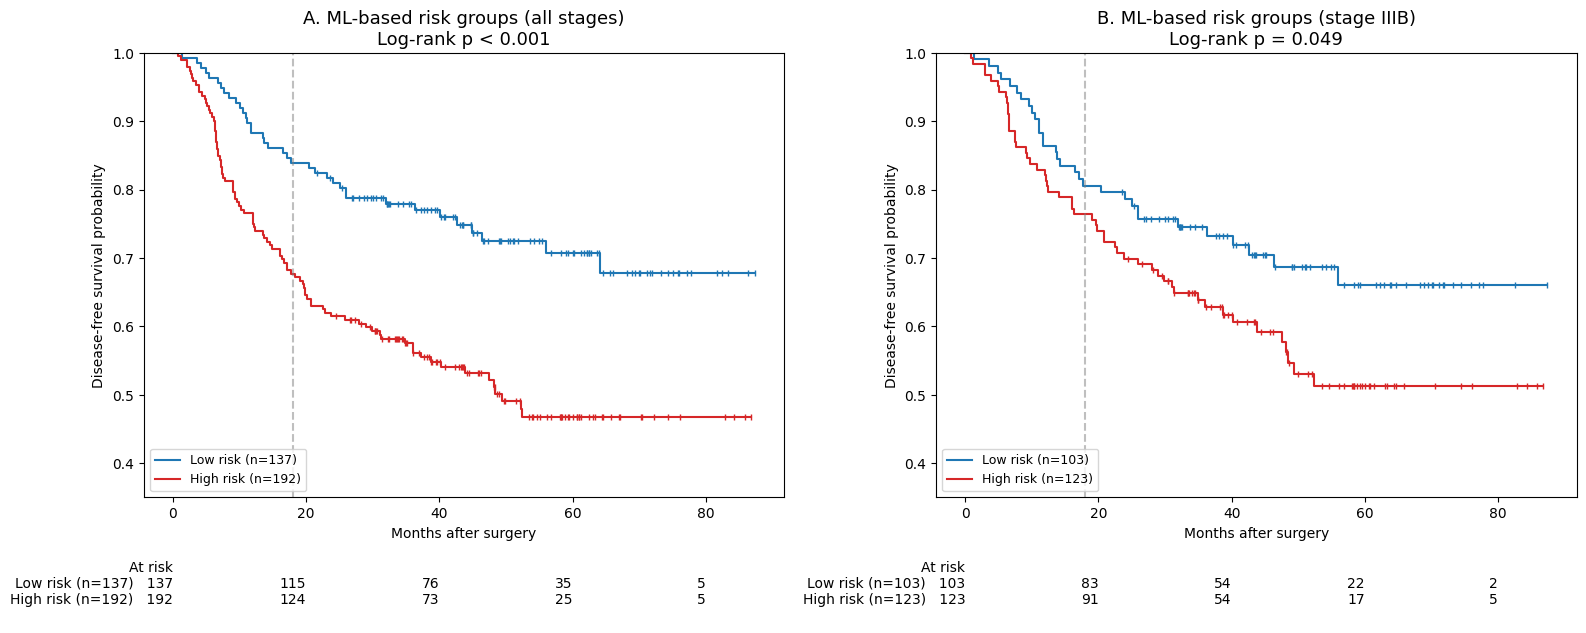

Fig 3A p=0.0000 | Fig 3B p=0.0486


In [2]:
def ptxt(p): return 'Log-rank p < 0.001' if p<0.001 else 'Log-rank p = %.3f'%p
def km_two(ax,data,title):
    hi=data[data['ML_Prob']>=CUT]; lo=data[data['ML_Prob']<CUT]
    kl=KaplanMeierFitter(label='Low risk (n=%d)'%len(lo)).fit(lo['DFS_Months'],lo['DFS_Event'])
    kh=KaplanMeierFitter(label='High risk (n=%d)'%len(hi)).fit(hi['DFS_Months'],hi['DFS_Event'])
    kl.plot_survival_function(ax=ax,color=LOW,ci_show=False,show_censors=True,censor_styles={'ms':5,'marker':'|'})
    kh.plot_survival_function(ax=ax,color=HIGH,ci_show=False,show_censors=True,censor_styles={'ms':5,'marker':'|'})
    lr=logrank_test(lo['DFS_Months'],hi['DFS_Months'],lo['DFS_Event'],hi['DFS_Event'])
    ax.set_title('%s\n%s'%(title,ptxt(lr.p_value)),fontsize=13)
    ax.set_xlabel('Months after surgery'); ax.set_ylabel('Disease-free survival probability')
    ax.axvline(x=18,color='gray',linestyle='--',alpha=0.5); ax.set_ylim(0.35,1.0); ax.legend(loc='lower left',fontsize=9)
    add_at_risk_counts(kl,kh,ax=ax,rows_to_show=['At risk'])
    return lr.p_value
fig,axes=plt.subplots(1,2,figsize=(16,6.5))
pA=km_two(axes[0],df,'A. ML-based risk groups (all stages)')
iiib=df[df['AJCC_Substage'].astype(str).str.contains('B')]
pB=km_two(axes[1],iiib,'B. ML-based risk groups (stage IIIB)')
plt.tight_layout()
plt.savefig('Figure_3_ML_risk_DFS.tiff',dpi=600,format='tiff',bbox_inches='tight')
plt.savefig('Figure_3_ML_risk_DFS.png',dpi=300,bbox_inches='tight'); plt.show()
print('Fig 3A p=%.4f | Fig 3B p=%.4f'%(pA,pB))

## Figure S2 — DFS by AJCC substage

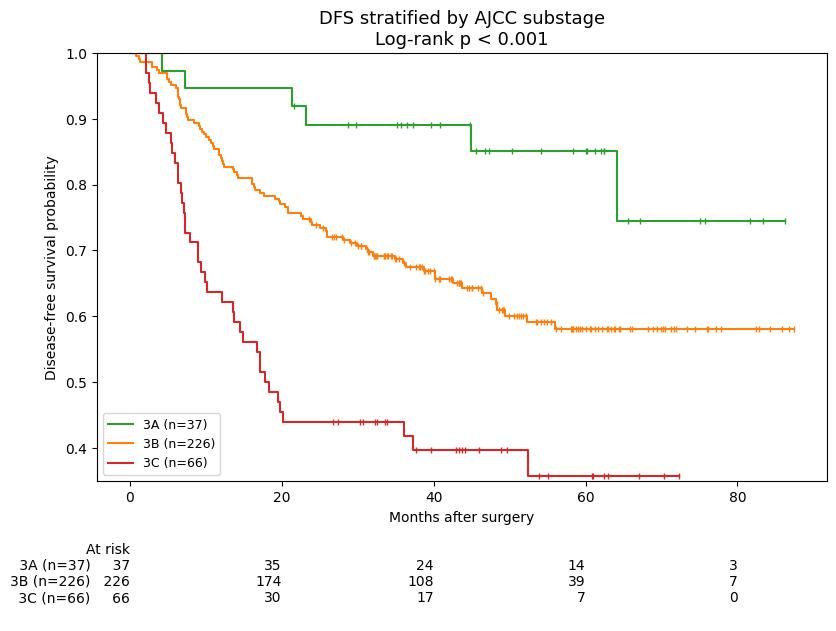

Fig S2 AJCC log-rank p=3.796e-07


In [3]:
fig,ax=plt.subplots(figsize=(8.5,6.5))
pal={'3A':'#2ca02c','3B':'#ff7f0e','3C':'#d62728'}
kms=[]
for g in sorted(df['AJCC_Substage'].dropna().unique()):
    m=df['AJCC_Substage']==g
    k=KaplanMeierFitter(label='%s (n=%d)'%(g,int(m.sum()))).fit(df.loc[m,'DFS_Months'],df.loc[m,'DFS_Event'])
    k.plot_survival_function(ax=ax,color=pal.get(str(g)),ci_show=False,show_censors=True,censor_styles={'ms':5,'marker':'|'}); kms.append(k)
pv=multivariate_logrank_test(df['DFS_Months'],df['AJCC_Substage'],df['DFS_Event']).p_value
ax.set_title('DFS stratified by AJCC substage\n%s'%('Log-rank p < 0.001' if pv<0.001 else 'Log-rank p = %.3f'%pv),fontsize=13)
ax.set_xlabel('Months after surgery'); ax.set_ylabel('Disease-free survival probability'); ax.set_ylim(0.35,1.0); ax.legend(loc='lower left',fontsize=9)
add_at_risk_counts(*kms,ax=ax,rows_to_show=['At risk'])
plt.tight_layout()
plt.savefig('Figure_S2_AJCC_DFS.tiff',dpi=600,format='tiff',bbox_inches='tight')
plt.savefig('Figure_S2_AJCC_DFS.png',dpi=300,bbox_inches='tight'); plt.show()
print('Fig S2 AJCC log-rank p=%.4g'%pv)